# Data

**Enunciado:** [Exercises → Data](https://insper.github.io/ann-dl/)

In [162]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
RNG = np.random.default_rng(SEED)
BASE = Path.cwd()
if not (BASE / "code").is_dir():
    BASE = Path("docs/exercises/data")
FIGURES = BASE / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

RESULTS = {}

## Exercício 1

### Nuvens de Pontos: Geometria e Espalhamento em 2D

### A — Gere as nuvens

400 amostras, 100 por classe, cada classe amostrada de uma gaussiana com desvios
independentes por eixo:

| Classe | $\mu$ | $\sigma$ |
|---|---|---|
| 0 | $[2,\ 3]$ | $[0{,}8,\ 2{,}5]$ |
| 1 | $[5,\ 6]$ | $[1{,}2,\ 1{,}9]$ |
| 2 | $[8,\ 1]$ | $[0{,}9,\ 0{,}9]$ |
| 3 | $[15,\ 4]$ | $[0{,}5,\ 2{,}0]$ |

O fator `scale` do item B multiplica só os desvios: as médias ficam onde estão, e a única
coisa que muda é o quanto cada nuvem se espalha em torno do seu centro. Isso é o que permite
atribuir qualquer perda de separabilidade à dispersão, e não ao deslocamento dos centros.

In [163]:
CLASSES = {
    0: {"mean": [2.0, 3.0], "std": [0.8, 2.5]},
    1: {"mean": [5.0, 6.0], "std": [1.2, 1.9]},
    2: {"mean": [8.0, 1.0], "std": [0.9, 0.9]},
    3: {"mean": [15.0, 4.0], "std": [0.5, 2.0]},
}
N_PER_CLASS = 100
CORES = {0: "#1f77b4", 1: "#d62728", 2: "#2ca02c", 3: "#9467bd"}


def generate(scale: float = 1.0) -> tuple[np.ndarray, np.ndarray]:
    """Amostra 100 pontos por classe, com os desvios multiplicados por ``scale``."""
    xs, ys = [], []
    for label, params in CLASSES.items():
        mean = np.asarray(params["mean"])
        std = np.asarray(params["std"]) * scale
        xs.append(RNG.normal(mean, std, size=(N_PER_CLASS, 2)))
        ys.append(np.full(N_PER_CLASS, label))
    return np.vstack(xs), np.concatenate(ys)

X, y = generate(1.0)
print("X:", X.shape, " y:", np.bincount(y))

pd.DataFrame(
    {
        "x1 médio": [X[y == c][:, 0].mean() for c in CLASSES],
        "x2 médio": [X[y == c][:, 1].mean() for c in CLASSES],
        "x1 desvio": [X[y == c][:, 0].std() for c in CLASSES],
        "x2 desvio": [X[y == c][:, 1].std() for c in CLASSES],
    },
    index=[f"Classe {c}" for c in CLASSES],
).round(3)

X: (400, 2)  y: [100 100 100 100]


,x1 médio,x2 médio,x1 desvio,x2 desvio
Classe 0,1.988,2.885,0.726,2.126
Classe 1,5.071,5.965,1.269,1.849
Classe 2,7.900,0.977,0.908,0.915
Classe 3,14.993,3.881,0.513,2.009


As médias e desvios empíricos batem com os parâmetros pedidos dentro do erro amostral
esperado para $n = 100$

Figura 1 traz o *scatter* das quatro classes com os centros marcados (`×`) e, ao fundo, as
regiões do classificador de centróide mais próximo, as fronteiras lineares por partes que
um modelo simples enxergaria. É esse sombreado que responde "onde cairiam as fronteiras".

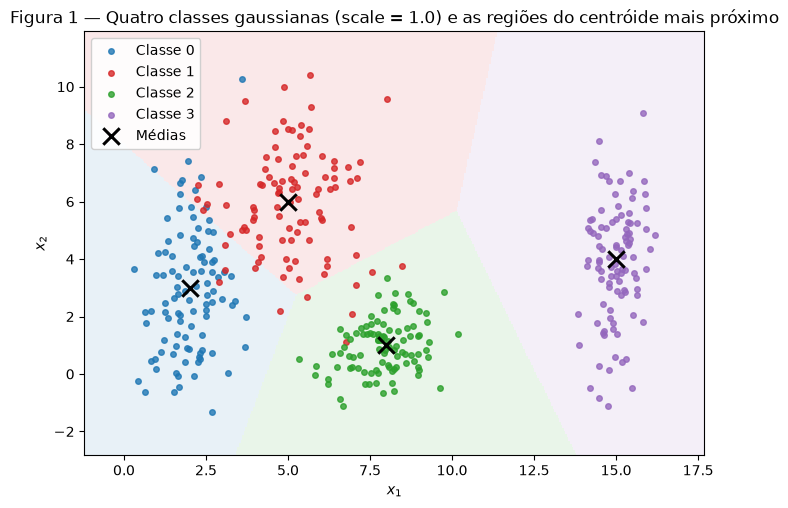

In [164]:
MEANS = np.stack([CLASSES[c]["mean"] for c in CLASSES])


def regioes_centroide(ax, xlim, ylim, passo=400):
    '''Pinta ao fundo a região atribuída a cada classe pelo centróide mais próximo.'''
    gx, gy = np.meshgrid(np.linspace(*xlim, passo), np.linspace(*ylim, passo))
    grade = np.column_stack([gx.ravel(), gy.ravel()])
    dist = np.linalg.norm(grade[:, None, :] - MEANS[None, :, :], axis=2)
    ax.pcolormesh(
        gx, gy, dist.argmin(axis=1).reshape(gx.shape),
        cmap=plt.matplotlib.colors.ListedColormap([CORES[c] for c in CLASSES]),
        alpha=0.10, shading="auto", zorder=0,
    )


fig, ax = plt.subplots(figsize=(8, 5.5))
xlim = (X[:, 0].min() - 1.5, X[:, 0].max() + 1.5)
ylim = (X[:, 1].min() - 1.5, X[:, 1].max() + 1.5)
regioes_centroide(ax, xlim, ylim)
for c in CLASSES:
    ax.scatter(*X[y == c].T, s=16, alpha=0.8, color=CORES[c], label=f"Classe {c}", zorder=2)
ax.scatter(*MEANS.T, marker="x", s=140, c="black", linewidths=2.2, zorder=3, label="Médias")
ax.set(xlim=xlim, ylim=ylim, xlabel="$x_1$", ylabel="$x_2$",
       title="Figura 1 — Quatro classes gaussianas (scale = 1.0) e as regiões do centróide mais próximo")
ax.legend(loc="upper left", framealpha=0.9)
fig.savefig(FIGURES / "fig01-point-clouds.png", bbox_inches="tight")
plt.show()

### B — Mais ou menos espalhado

A razão de separação de um par de classes,

$$
r_{ij} = \frac{\lVert \mu_i - \mu_j \rVert}{\bar{\sigma}_i + \bar{\sigma}_j},
\qquad
\bar{\sigma}_k = \frac{\sigma_{k,x} + \sigma_{k,y}}{2},
$$

compara a distância entre os centros com o espalhamento típico das duas nuvens: $r_{ij} > 1$
significa que os centros estão mais longe um do outro do que as nuvens são largas. Como
`scale` multiplica todos os desvios e não mexe nas médias, vale exatamente
$r_{ij}(s) = r_{ij}(1)/s$ — a razão é inversamente proporcional ao espalhamento, e é por isso
que a tabela abaixo traz os seis pares nos quatro valores de $s$ de uma vez.

In [165]:
SCALES = (0.5, 1.0, 2.0, 4.0)
PARES = [(i, j) for i in CLASSES for j in CLASSES if i < j]


def separation_ratio(i: int, j: int, scale: float = 1.0) -> float:
    mi, mj = np.asarray(CLASSES[i]["mean"]), np.asarray(CLASSES[j]["mean"])
    sigma = (np.mean(CLASSES[i]["std"]) + np.mean(CLASSES[j]["std"])) * scale
    return float(np.linalg.norm(mi - mj) / sigma)

def mixing_rate(X: np.ndarray, y: np.ndarray) -> float:
    dist = np.linalg.norm(X[:, None, :] - MEANS[None, :, :], axis=2)
    return float((dist.argmin(axis=1) != y).mean())


for s in SCALES:
    RNG = np.random.default_rng(SEED)
    RESULTS[f"taxa de mistura (s={s})"] = mixing_rate(*generate(s))

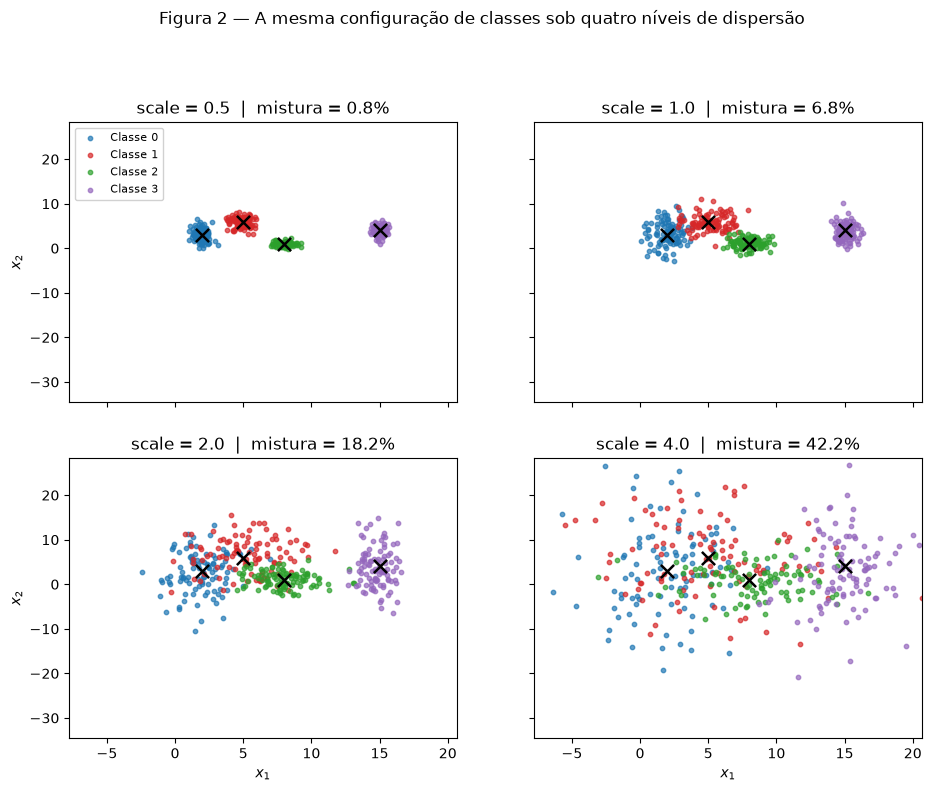

In [166]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
X_max, _ = generate(max(SCALES))
lim_x = (X_max[:, 0].min() - 1, X_max[:, 0].max() + 1)
lim_y = (X_max[:, 1].min() - 1, X_max[:, 1].max() + 1)

for ax, s in zip(axes.ravel(), SCALES):
    Xs, ys = generate(s)
    for c in CLASSES:
        ax.scatter(*Xs[ys == c].T, s=10, alpha=0.7, color=CORES[c], label=f"Classe {c}")
    ax.scatter(*MEANS.T, marker="x", s=90, c="black", linewidths=1.8)
    ax.set(title=f"scale = {s}  |  mistura = {mixing_rate(Xs, ys):.1%}", xlim=lim_x, ylim=lim_y)

for ax in axes[1]:
    ax.set_xlabel("$x_1$")
for ax in axes[:, 0]:
    ax.set_ylabel("$x_2$")
axes[0, 0].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle("Figura 2 — A mesma configuração de classes sob quatro níveis de dispersão", y=1.02)
fig.savefig(FIGURES / "fig02-scales.png", bbox_inches="tight")
plt.show()

In [167]:
tabela_r = pd.DataFrame(
    {f"s = {s}": [separation_ratio(i, j, s) for i, j in PARES] for s in SCALES},
    index=[f"Classe {i} vs {j}" for i, j in PARES],
).round(3)

RESULTS['Menor rij em s = 1.0 e pior par'] = f"{tabela_r['s = 1.0'].idxmin()} (r = {tabela_r['s = 1.0'].min():.3f})"
print(f"par mais frágil em s = 1.0: {tabela_r['s = 1.0'].idxmin()}"
      f" (r = {tabela_r['s = 1.0'].min():.3f})")
print(f"pares com r < 1 por escala:",
      {f"s={s}": int((tabela_r[f's = {s}'] < 1).sum()) for s in SCALES})
print("Tabela 1 — razão de separação por par de classes")
tabela_r

par mais frágil em s = 1.0: Classe 0 vs 1 (r = 1.326)
pares com r < 1 por escala: {'s=0.5': 0, 's=1.0': 0, 's=2.0': 1, 's=4.0': 5}
Tabela 1 — razão de separação por par de classes


,s = 0.5,s = 1.0,s = 2.0,s = 4.0
Classe 0 vs 1,2.652,1.326,0.663,0.331
Classe 0 vs 2,4.960,2.480,1.240,0.620
Classe 0 vs 3,8.992,4.496,2.248,1.124
Classe 1 vs 2,4.760,2.380,1.190,0.595
Classe 1 vs 3,7.284,3.642,1.821,0.911
Classe 2 vs 3,7.084,3.542,1.771,0.886


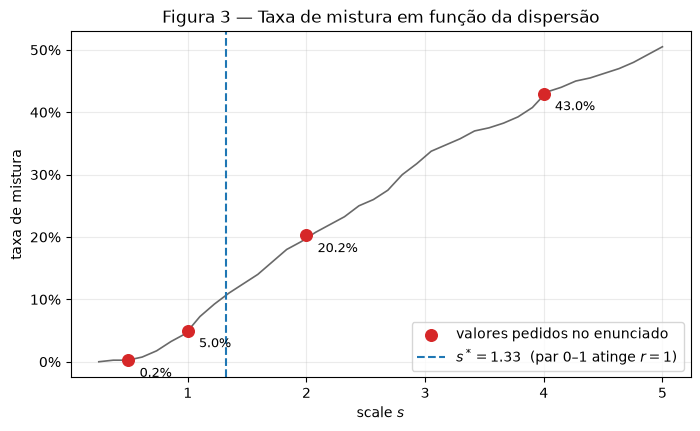

In [168]:
s_grid = np.linspace(0.25, 5.0, 40)
mistura_grid = []
for s in s_grid:
    RNG = np.random.default_rng(SEED)
    mistura_grid.append(mixing_rate(*generate(s)))

s_critico = min(separation_ratio(i, j) for i, j in PARES)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(s_grid, mistura_grid, color="#444", lw=1.2, alpha=0.8)
ax.scatter(SCALES, [RESULTS[f"taxa de mistura (s={s})"] for s in SCALES],
            s=70, color="#d62728", zorder=3, label="valores pedidos no enunciado")
for s in SCALES:
    ax.annotate(f"{RESULTS[f'taxa de mistura (s={s})']:.1%}",
                (s, RESULTS[f"taxa de mistura (s={s})"]),
                textcoords="offset points", xytext=(8, -12), fontsize=9)
ax.axvline(s_critico, ls="--", color="#1f77b4",
            label=f"$s^* = {s_critico:.2f}$  (par 0–1 atinge $r = 1$)")
ax.set(xlabel="scale $s$", ylabel="taxa de mistura",
        title="Figura 3 — Taxa de mistura em função da dispersão")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.grid(alpha=0.25)
ax.legend()
fig.savefig(FIGURES / "fig03-mixing-rate.png", bbox_inches="tight")
plt.show()

### C — Análise

1. No dataset original, 3 das 4 classes se sobrepõe, a única que fica mais isolada do resto é a classe 3 que forma praticamente uma reta em x ~= 15. Uma fronteira linear não seria o suficiente para separar todas as classes, porém uma reta por classe seria o suficiente, como foi esboçado na figura 1. Porém de qualquer forma temos as classes se sobrepondo de alguma forma, é impossível separar com apenas retas.

3. Quanto mais espalhadas as nuvens, mais é a taxa de mistura, e isso varia quase que linearmente, portanto, em escalas menores, temos uma menos taxa de mistura entre elas. Observado na figura 3.

## Exercise 2

### Não-Linearidade em Dimensões Maiores

### A — Dataset I: gaussianas deslocadas

In [169]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

SIGMA_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])
SIGMA_B = np.array([
    [1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7, 1.5, 0.4, 0.0, 0.0],
    [0.2, 0.4, 1.5, 0.6, 0.0],
    [0.0, 0.0, 0.6, 1.5, 0.3],
    [0.0, 0.0, 0.0, 0.3, 1.5],
])
N_5D = 500

### B — Dataset II: cascas concêntricas

In [170]:
rng = np.random.default_rng(SEED)

X_A = rng.multivariate_normal(np.zeros(5), SIGMA_A, size=N_5D)
X_B = rng.multivariate_normal(np.full(5, 1.5), SIGMA_B, size=N_5D)
X_I = np.vstack([X_A, X_B])
y_I = np.r_[np.zeros(N_5D, int), np.ones(N_5D, int)]


def casca(n: int, raio_medio: float, raio_std: float, rng) -> np.ndarray:
    '''Pontos numa casca esférica de R^5: direção uniforme × raio gaussiano.'''
    direcao = rng.normal(size=(n, 5))
    direcao /= np.linalg.norm(direcao, axis=1, keepdims=True)
    raio = rng.normal(raio_medio, raio_std, size=(n, 1))
    return direcao * raio


X_C = casca(N_5D, 2.0, 0.4, rng)
X_D = casca(N_5D, 5.0, 0.4, rng)
X_II = np.vstack([X_C, X_D])
y_II = np.r_[np.zeros(N_5D, int), np.ones(N_5D, int)]

print("Conjunto I :", X_I.shape, "| Conjunto II:", X_II.shape)

Conjunto I : (1000, 5) | Conjunto II: (1000, 5)


### C — Visualize e compare

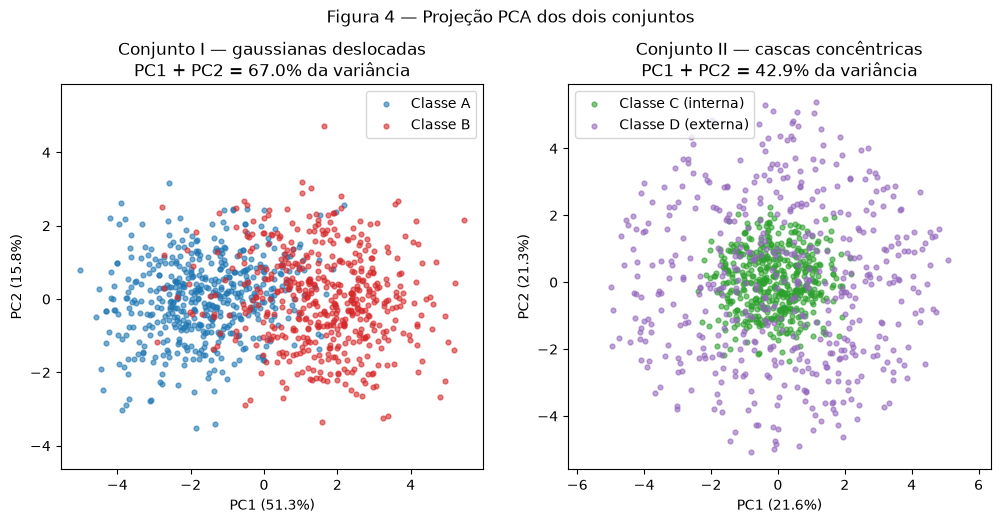

,PC1,PC2,PC1+PC2,distância entre centros (5D)
conjunto,,,,
Conjunto I,0.5127,0.1577,0.6704,3.2643
Conjunto II,0.2159,0.2132,0.4291,0.2662


In [171]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
resumo_pca = []

for ax, (nome, Xd, yd, rotulos, cores) in zip(axes, [
    ("Conjunto I — gaussianas deslocadas", X_I, y_I, ("Classe A", "Classe B"), ("#1f77b4", "#d62728")),
    ("Conjunto II — cascas concêntricas", X_II, y_II, ("Classe C (interna)", "Classe D (externa)"), ("#2ca02c", "#9467bd")),
]):
    pca = PCA(n_components=2).fit(Xd)
    Z = pca.transform(Xd)
    ev = pca.explained_variance_ratio_
    for k in (0, 1):
        ax.scatter(*Z[yd == k].T, s=12, alpha=0.6, color=cores[k], label=rotulos[k])
    ax.set(xlabel=f"PC1 ({ev[0]:.1%})", ylabel=f"PC2 ({ev[1]:.1%})",
           title=f"{nome}\nPC1 + PC2 = {ev.sum():.1%} da variância")
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend()
    centros = np.stack([Xd[yd == 0].mean(0), Xd[yd == 1].mean(0)])
    resumo_pca.append({
        "conjunto": nome.split(" — ")[0],
        "PC1": ev[0], "PC2": ev[1], "PC1+PC2": ev.sum(),
        "distância entre centros (5D)": float(np.linalg.norm(centros[0] - centros[1])),
    })

fig.suptitle("Figura 4 — Projeção PCA dos dois conjuntos", y=1.03)
fig.savefig(FIGURES / "fig04-pca.png", bbox_inches="tight")
plt.show()

tabela_pca = pd.DataFrame(resumo_pca).set_index("conjunto").round(4)
for linha in tabela_pca.index:
    RESULTS[f"PC1+PC2 — {linha}"] = tabela_pca.loc[linha, "PC1+PC2"]
    RESULTS[f"dist. centros 5D — {linha}"] = tabela_pca.loc[linha, "distância entre centros (5D)"]
tabela_pca

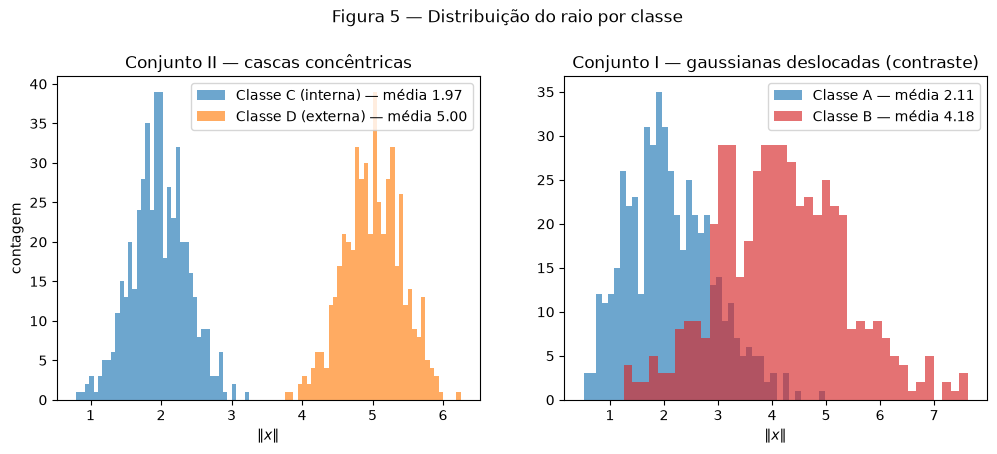

Classe C (interna): raio médio 1.972 ± 0.396
Classe D (externa): raio médio 5.005 ± 0.409


In [172]:
raios = {"Classe C (interna)": np.linalg.norm(X_C, axis=1),
         "Classe D (externa)": np.linalg.norm(X_D, axis=1)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for nome, r in raios.items():
    axes[0].hist(r, bins=40, alpha=0.65, label=f"{nome} — média {r.mean():.2f}")
axes[0].set(xlabel=r"$\|x\|$", ylabel="contagem", title="Conjunto II — cascas concêntricas")
axes[0].legend()

for nome, Xd, cor in [("Classe A", X_A, "#1f77b4"), ("Classe B", X_B, "#d62728")]:
    r = np.linalg.norm(Xd, axis=1)
    axes[1].hist(r, bins=40, alpha=0.65, color=cor, label=f"{nome} — média {r.mean():.2f}")
axes[1].set(xlabel=r"$\|x\|$", title="Conjunto I — gaussianas deslocadas (contraste)")
axes[1].legend()

fig.suptitle("Figura 5 — Distribuição do raio por classe", y=1.04)
fig.savefig(FIGURES / "fig05-raios.png", bbox_inches="tight")
plt.show()

for nome, r in raios.items():
    print(f"{nome}: raio médio {r.mean():.3f} ± {r.std():.3f}")

### D — Análise

1. Dá para separar as classes, só que não com um hiperplano. A distância entre os centros no Dataset II é $0{,}27$ (contra $3{,}26$ no Dataset I), mas os raios médios são $1{,}97$ e $5{,}01$, com desvio de $0{,}40$. Como as duas classes têm o mesmo centro, qualquer plano passa no meio delas e deixa metade de cada uma de cada lado. A informação que separa está na
distância até o centro, e o plano só olha para que lado o ponto está.

2. Porque o problema é o formato, não a quantidade. Se $x$ está na casca de dentro, $-x$ também está — a casca é uma esfera, igual para todo lado. Mas $f(x) = w^\top x + b$ vira $f(-x) = -w^\top x + b$, e para os dois darem o mesmo sinal em todos os pontos só com $w = 0$, que é o modelo que responde a mesma coisa para todo mundo: 50%, igual a chutar.

3. Não. A PCA busca as direções de maior espalhamento, não as que separam as classes, ela nem olha o rótulo. No Dataset II a PC1 pegou $21{,}6\%$ e a PC2 $21{,}3\%$: nenhuma direção é melhor que a outra, porque a nuvem é uma bola. No Dataset I a PC1 sozinha pegou $51{,}3\%$, porque lá existe a direção que liga um centro ao outro. A prova de que dá para separar é a
Figura 5: mesmo dado, olhando o raio.

Uma função que separa:

$$
g(x) = \lVert x \rVert^2 - 12{,}25 = x_1^2 + \dots + x_5^2 - 3{,}5^2 ,
$$

com $g < 0$ para a classe C e $g > 0$ para a D. O $3{,}5$ é o meio do caminho entre $1{,}97$ e $5{,}01$. Ela eleva cada coordenada ao quadrado, então não é linear — um perceptron só multiplica por peso e soma. É essa conta que a camada escondida precisa construir.

## Exercise 3

### Preparando Dados do Mundo Real para uma Rede Neural

### A — Conheça os dados

Objetivo do dataset. O Spaceship Titanic é um navio que bateu numa anomalia do espaço-tempo. Parte dos passageiros foi jogada para outra dimensão, e cada linha do `train.csv` é um passageiro, com o que se sabia dele na viagem: planeta de origem, destino, idade, se estava em hibernação (`CryoSleep`), cabine, se era VIP e quanto gastou em cada um
dos cinco serviços de bordo.

A coluna `Transported` é o alvo, e é booleana: `True` quer dizer que o passageiro foi transportado para a outra dimensão, `False` que ele continuou a bordo. A tarefa é prever esse `True`/`False` a partir das outras colunas, classificação binária. Como ela é o que a rede deve aprender, sai de `X` e vai para `y`; deixá-la nas features seria entregar a resposta.

In [173]:
import urllib.request

CSV = BASE / "code" / "train.csv"
if not CSV.exists():
    CSV.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://huggingface.co/datasets/StevenSch12/spaceship-titanic-train/resolve/main/train.csv",
        CSV,
    )

df = pd.read_csv(CSV)
print("shape:", df.shape)
df.head()

shape: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [174]:
inventario = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "valores únicos": df.nunique(),
    "ausentes": df.isna().sum(),
})
inventario["tipo"] = np.where(
    df.columns.isin(["PassengerId", "Name", "Cabin"]), "identificador",
    np.where(df.dtypes == "float64", "numérica", "categórica"),
)
inventario.sort_values("tipo")

,dtype,valores únicos,ausentes,tipo
HomePlanet,str,3,201,categórica
CryoSleep,object,2,217,categórica
Destination,str,3,182,categórica
VIP,object,2,203,categórica
Transported,bool,2,0,categórica
PassengerId,str,8693,0,identificador
Cabin,str,6560,199,identificador
Name,str,8473,200,identificador
Age,float64,80,179,numérica
RoomService,float64,1273,181,numérica


In [175]:
balanco = df["Transported"].value_counts(normalize=True)
RESULTS["classe positiva (Transported)"] = float(balanco[True])
print("Balanço do alvo:", {str(k): f"{v:.2%}" for k, v in balanco.items()},
      "— praticamente 50/50, não há desbalanceamento a corrigir.")

ausentes = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "% do total": (df.isna().mean() * 100).round(2),
})
ausentes = ausentes[ausentes["ausentes"] > 0].sort_values("ausentes", ascending=False)
print(f"\n{len(ausentes)} das {df.shape[1]} colunas têm valores ausentes:")
ausentes

Balanço do alvo: {'True': '50.36%', 'False': '49.64%'} — praticamente 50/50, não há desbalanceamento a corrigir.

12 das 14 colunas têm valores ausentes:


,ausentes,% do total
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
FoodCourt,183,2.11
Spa,183,2.11
Destination,182,2.09


In [176]:
GASTOS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

estatisticas = df[GASTOS].agg(["mean", "median", "max"]).T
estatisticas["assimetria"] = df[GASTOS].skew()
estatisticas["% de zeros"] = (df[GASTOS] == 0).mean() * 100
RESULTS['Média e mediana de FoodCourt'] = f"{estatisticas['mean']['FoodCourt']}, {estatisticas['median']['FoodCourt']}"
print("Colunas de gasto — a média é ordens de grandeza maior que a mediana:")
estatisticas.round(2)

Colunas de gasto — a média é ordens de grandeza maior que a mediana:


,mean,median,max,assimetria,% de zeros
RoomService,224.69,0.0,14327.0,6.33,64.16
FoodCourt,458.08,0.0,29813.0,7.10,62.76
ShoppingMall,173.73,0.0,23492.0,12.63,64.27
Spa,311.14,0.0,22408.0,7.64,61.24
VRDeck,304.85,0.0,24133.0,7.82,63.21


Nenhuma coluna passa de $2{,}5\%$ de ausentes, descartar as linhas incompletas custaria perto de um quarto do dataset (12 colunas independentes com $\approx 2\%$ cada), então imputar é claramente melhor. As cinco colunas de gasto têm **mediana zero** e assimetria entre $6{,}3$ e $12{,}6$: mais de $60\%$ dos passageiros não gastaram nada em cada serviço, e uma minoria gastou dezenas de milhares. É a distribuição em L que o $\log(1+x)$ existe para tratar.

### B — Separe antes de transformar

In [177]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

DESCARTAR = ["Cabin", "Name", "PassengerId"]
NUMERICAS = ["Age"] + GASTOS
CATEGORICAS = ["HomePlanet", "Destination"]
BINARIAS = ["CryoSleep", "VIP"]

y_alvo = df["Transported"].astype(int)
X_bruto = df.drop(columns=["Transported", *DESCARTAR])

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_bruto, y_alvo, test_size=0.2, stratify=y_alvo, random_state=SEED
)

Cada tipo pede um tratamento diferente: numérica se imputa com a mediana e se escalona, categórica se imputa com a moda e se codifica em one-hot escalonar HomePlanet ou tirar a mediana de TRAPPIST-1e não significa nada. Por isso a classificação das colunas precisa estar decidida antes, senão não há como escolher qual transformador aplicar em qual coluna.

In [178]:
imputador_num = SimpleImputer(strategy="median").fit(X_treino[NUMERICAS])
imputador_cat = SimpleImputer(strategy="most_frequent").fit(
    X_treino[CATEGORICAS + BINARIAS].astype(object)
)
codificador = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(
    pd.DataFrame(imputador_cat.transform(X_treino[CATEGORICAS + BINARIAS].astype(object)),
                 columns=CATEGORICAS + BINARIAS)[CATEGORICAS]
)

print("medianas do treino:", dict(zip(NUMERICAS, imputador_num.statistics_.round(2))))
print("modas do treino   :", dict(zip(CATEGORICAS + BINARIAS, imputador_cat.statistics_)))
print("categorias vistas :", {c: list(v) for c, v in zip(CATEGORICAS, codificador.categories_)})

medianas do treino: {'Age': np.float64(27.0), 'RoomService': np.float64(0.0), 'FoodCourt': np.float64(0.0), 'ShoppingMall': np.float64(0.0), 'Spa': np.float64(0.0), 'VRDeck': np.float64(0.0)}
modas do treino   : {'HomePlanet': 'Earth', 'Destination': 'TRAPPIST-1e', 'CryoSleep': False, 'VIP': False}
categorias vistas : {'HomePlanet': ['Earth', 'Europa', 'Mars'], 'Destination': ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']}


In [179]:
def transformar(X_in: pd.DataFrame) -> pd.DataFrame:
    '''Imputa, engenheira TotalSpend, aplica log1p e codifica — sempre com estatísticas do treino.'''
    num = pd.DataFrame(imputador_num.transform(X_in[NUMERICAS]),
                       columns=NUMERICAS, index=X_in.index)
    cat = pd.DataFrame(imputador_cat.transform(X_in[CATEGORICAS + BINARIAS].astype(object)),
                       columns=CATEGORICAS + BINARIAS, index=X_in.index)

    num["TotalSpend"] = num[GASTOS].sum(axis=1)
    for coluna in GASTOS + ["TotalSpend"]:
        num[coluna] = np.log1p(num[coluna])

    for coluna in BINARIAS:
        num[coluna] = cat[coluna].map({True: 1.0, False: 0.0}).astype(float)

    dummies = pd.DataFrame(codificador.transform(cat[CATEGORICAS]),
                           columns=codificador.get_feature_names_out(CATEGORICAS),
                           index=X_in.index)
    return pd.concat([num, dummies], axis=1)


treino_t = transformar(X_treino)
teste_t = transformar(X_teste)

escalonador = MinMaxScaler(feature_range=(-1, 1)).fit(treino_t)
X_treino_final = pd.DataFrame(escalonador.transform(treino_t),
                              columns=treino_t.columns, index=treino_t.index)
X_teste_final = pd.DataFrame(escalonador.transform(teste_t),
                             columns=teste_t.columns, index=teste_t.index)

print("features finais:", list(X_treino_final.columns))
print("Shape final:", X_treino_final.shape)
RESULTS['shape final'] = f"{X_treino_final.shape}"
X_treino_final.head()

features finais: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'CryoSleep', 'VIP', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
Shape final: (6954, 15)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,CryoSleep,VIP,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
3600,-1.000000,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0
1262,-0.569620,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0
8612,-0.113924,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0
5075,-0.341772,-1.0,-1.0,-1.00000,-1.000000,-1.000000,-1.00000,1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0
4758,-0.670886,-1.0,-1.0,-0.12661,-0.861609,0.723023,0.63153,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0


`TotalSpend` é a soma dos cinco serviços, calculada **depois** da imputação (somar com `NaN` propagaria o vazio) e **antes** do log — o log de uma soma não é a soma dos logs, e o que interessa é o gasto total em unidades monetárias, comprimido depois. Note que ela é a única feature realmente nova; as demais são as originais recodificadas.

### D — Verifique e visualize

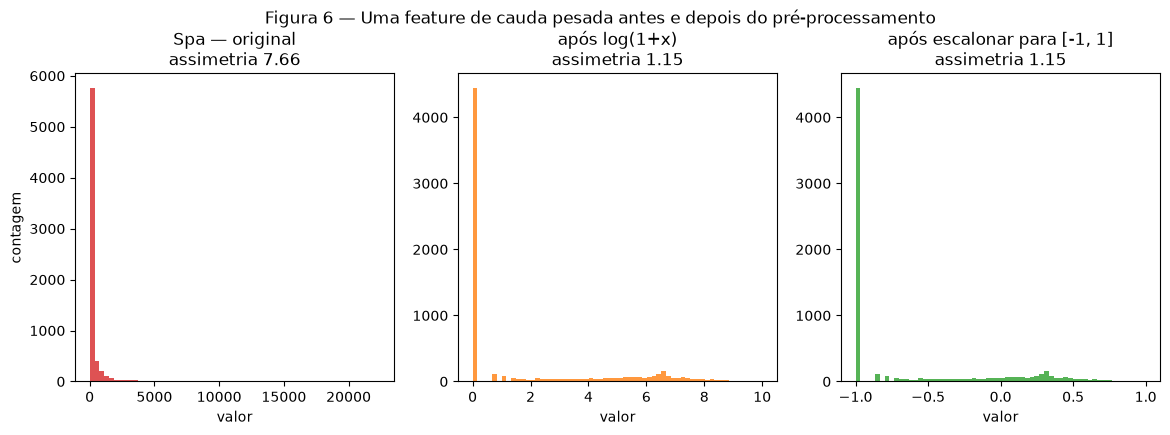

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
coluna = "Spa"

axes[0].hist(X_treino[coluna].dropna(), bins=60, color="#d62728", alpha=0.8)
axes[0].set(title=f"{coluna} — original\nassimetria {X_treino[coluna].skew():.2f}",
            xlabel="valor", ylabel="contagem")

axes[1].hist(treino_t[coluna], bins=60, color="#ff7f0e", alpha=0.8)
axes[1].set(title=f"após log(1+x)\nassimetria {treino_t[coluna].skew():.2f}", xlabel="valor")

axes[2].hist(X_treino_final[coluna], bins=60, color="#2ca02c", alpha=0.8)
axes[2].set(title=f"após escalonar para [-1, 1]\nassimetria {X_treino_final[coluna].skew():.2f}",
            xlabel="valor")

fig.suptitle("Figura 6 — Uma feature de cauda pesada antes e depois do pré-processamento", y=1.04)
fig.savefig(FIGURES / "fig06-spa-antes-depois.png", bbox_inches="tight")
plt.show()

In [181]:
faixa_treino = (X_treino_final.to_numpy().min(), X_treino_final.to_numpy().max())
faixa_teste = (X_teste_final.to_numpy().min(), X_teste_final.to_numpy().max())
RESULTS["faixa das features (treino)"] = f"[{faixa_treino[0]:.2f}, {faixa_treino[1]:.2f}]"
RESULTS["faixa das features (teste)"] = f"[{faixa_teste[0]:.2f}, {faixa_teste[1]:.4f}]"

print(f"shape final      : treino {X_treino_final.shape} | teste {X_teste_final.shape}")
print(f"faixa dos valores: treino [{faixa_treino[0]:.2f}, {faixa_treino[1]:.2f}]"
      f" | teste [{faixa_teste[0]:.2f}, {faixa_teste[1]:.4f}]")
print(f"NaN restantes    : treino {int(X_treino_final.isna().sum().sum())}"
      f" | teste {int(X_teste_final.isna().sum().sum())}")
print(f"dtypes           : {set(map(str, X_treino_final.dtypes))}")

X_treino_final.describe().T[["min", "mean", "max"]].round(3)

shape final      : treino (6954, 15) | teste (1739, 15)
faixa dos valores: treino [-1.00, 1.00] | teste [-1.00, 1.1383]
NaN restantes    : treino 0 | teste 0
dtypes           : {'float64'}


,min,mean,max
Age,-1.0,-0.275,1.0
RoomService,-1.0,-0.633,1.0
FoodCourt,-1.0,-0.635,1.0
ShoppingMall,-1.0,-0.665,1.0
Spa,-1.0,-0.639,1.0
VRDeck,-1.0,-0.648,1.0
TotalSpend,-1.0,-0.194,1.0
CryoSleep,-1.0,-0.299,1.0
VIP,-1.0,-0.954,1.0
HomePlanet_Earth,-1.0,0.105,1.0


### D. Análise

O teste passa um pouco de [-1, 1]. O treino fica exatamente nesse intervalo porque o escalonador foi ajustado nele, e o teste chega a 1,14, ou seja, tem um passageiro que gastou mais do que qualquer um do treino. Isso era esperado. Se eu tivesse ajustado o escalonador no dataset inteiro, os dois intervalos fechariam certinho, mas isso seria sinal de vazamento e não de qualidade. O excesso é pequeno e a tanh ainda funciona bem em 1,14, então não mexi. Se fosse grande, daria para clipar o teste ou usar padronização, que não tem borda fixa.

O log ajudou bastante. A assimetria do Spa cai de 7,66 para 1,15. O escalonamento depois disso não muda a assimetria, porque é uma transformação afim, só desloca e comprime, por isso os dois últimos painéis da Figura 6 têm o mesmo formato em escalas diferentes. O pico que sobra em -1 são os 61% de passageiros que não gastaram nada no spa. Nenhuma transformação monótona tira isso, e nem deveria tirar, já que é informação de verdade, provavelmente gente que estava em CryoSleep.

Na imputação usei mediana para as colunas numéricas e moda para as categóricas. Não usei média porque com assimetria acima de 6 a média fica puxada pelas caudas. Nos gastos a mediana é 0, o que na prática assume que quem não tem registro não gastou, e isso faz sentido aqui porque a maioria não gastou mesmo. Na Age a mediana do treino é 27.

No final sobraram 10 colunas depois dos descartes, que viraram 15 features: 6 numéricas originais, 1 criada por mim (TotalSpend), 2 binárias mapeadas para 0 e 1 e 6 colunas de one-hot, sendo 3 de HomePlanet e 3 de Destination. Não sobrou nenhum NaN nos dois conjuntos e tudo está em float64, pronto para entrar na rede.

## Results summary

Todos os valores abaixo são lidos do dicionário `RESULTS`, preenchido pelas células acima —
nenhum foi digitado à mão.

In [182]:
def formatar(chave, valor):
    if isinstance(valor, str):
        return valor
    if "taxa" in chave or "acurácia" in chave or "classe positiva" in chave:
        return f"{valor:.2%}"
    if isinstance(valor, (int, np.integer)):
        return f"{valor:,}".replace(",", " ")
    return f"{valor:.4f}"


pd.DataFrame(
    {"valor": [formatar(k, v) for k, v in RESULTS.items()]},
    index=pd.Index(RESULTS.keys(), name="métrica"),
)

,valor
métrica,
taxa de mistura (s=0.5),0.25%
taxa de mistura (s=1.0),5.00%
taxa de mistura (s=2.0),20.25%
taxa de mistura (s=4.0),43.00%
Menor rij em s = 1.0 e pior par,Classe 0 vs 1 (r = 1.326)
PC1+PC2 — Conjunto I,0.6704
dist. centros 5D — Conjunto I,3.2643
PC1+PC2 — Conjunto II,0.4291
dist. centros 5D — Conjunto II,0.2662


## Discussão

O que mais me confundiu foi perceber que as duas métricas do Exercício 1 respondem a perguntas diferentes. A razão de separação é teórica, usa só os parâmetros do enunciado, ignora a amostra e escala com 1/s. A taxa de mistura é empírica e depende da amostra sorteada. Fiquei um tempo tentando fazer uma bater com a outra, porque em s = 1 todos os pares têm r maior que 1 e mesmo assim 5% dos pontos se misturam. Não é contradição: r maior que 1 só diz que os centros estão mais longe do que a largura típica das nuvens, o que não impede as caudas de se cruzarem. Uma métrica fala de centros e a outra de pontos.

No Exercício 2 minha intuição também errou. Eu achava que a PCA das cascas ia mostrar pelo menos alguma separação parcial, e só entendi por que não mostra quando escrevi a simetria antipodal: se x e -x são da mesma classe, qualquer projeção linear dá sinais opostos para os dois, então não existe w que resolva. A regressão logística em 51,5% confirmou isso, e é o tipo de teste que eu teria pulado se tivesse olhado só a figura.

O que eu faria diferente: no Exercício 3 descartei Cabin porque o enunciado pediu, mas esse campo tem deck, número e lado, e o deck provavelmente é preditivo. Num projeto de verdade eu quebraria em três features antes de jogar fora. Também testaria padronização no lugar do MinMaxScaler, porque o estouro do teste em 1,14 não atrapalhou aqui, mas é um problema que a padronização não teria.

## Conclusão

Os três exercícios dizem a mesma coisa de formas diferentes: a geometria dos dados define a complexidade que a rede precisa ter, e capacidade nenhuma compensa um espaço de features ruim.

No Exercício 1 a fronteira é linear por partes e a dificuldade é só quantitativa. A partir de s perto de 1,33 o par 0-1 entra numa sobreposição que não tem como desfazer, e o erro que sobra não é falta de capacidade, é ruído. No Exercício 2 a dificuldade é de outro tipo: as cascas têm a mesma média e a informação de classe está na norma de x, que é uma estatística de segunda ordem. O mesmo classificador linear sai de 51,5% para 100% só por receber a feature certa, e é exatamente isso que as camadas ocultas de um MLP aprendem a montar. O Exercício 3 mostra que antes de pensar em arquitetura a escala já importa: uma feature com assimetria 7,66 entregue crua para uma tanh satura o neurônio e mata o gradiente, e o log(1+x) que baixa isso para 1,15 resolve mais do que uma camada a mais.

No fim das contas o pré-processamento não é só uma etapa chata antes do modelo, é onde se decide que fronteira o modelo vai ter que aprender.